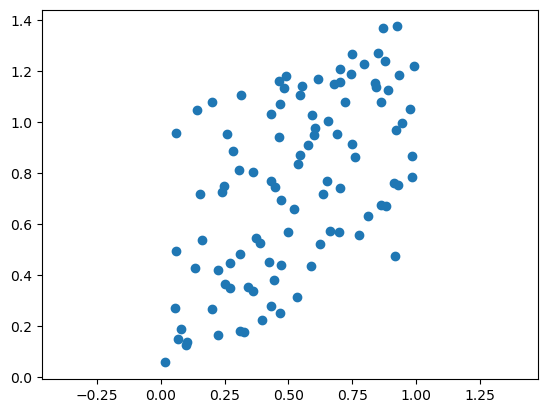

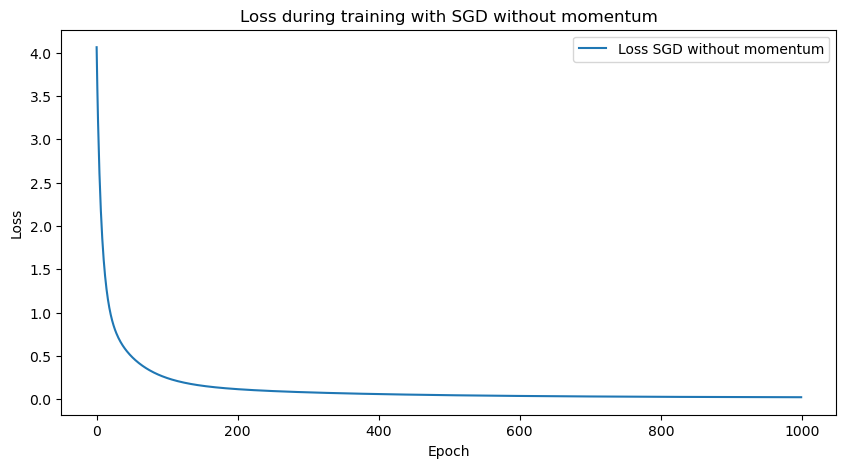

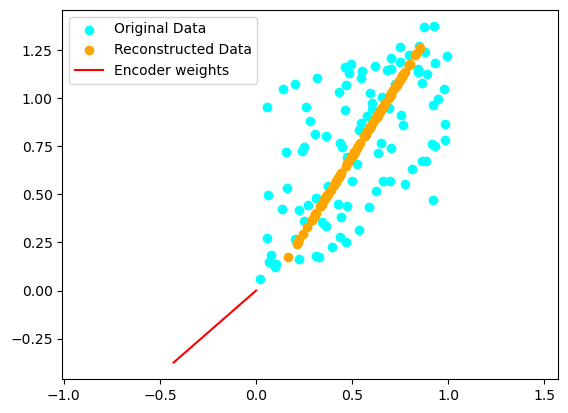

Ratio of encoder weight to decoder weight for dimension 0: 0.5515311072676302
Ratio of encoder weight to decoder weight for dimension 1: 0.3032551788374695


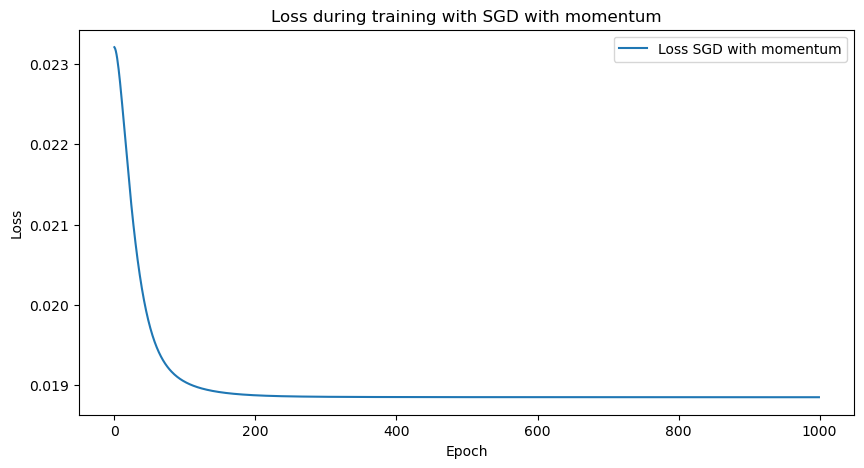

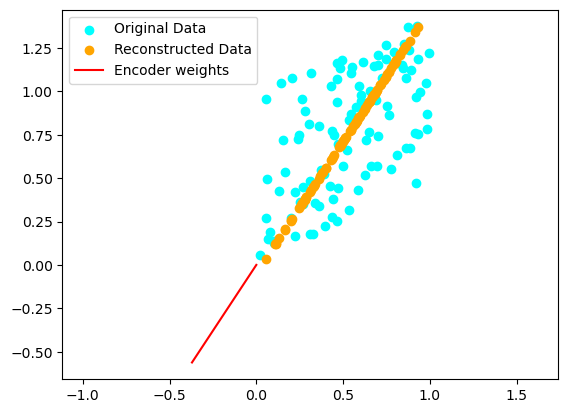

Ratio of encoder weight to decoder weight for dimension 0: 0.45365058274923925
Ratio of encoder weight to decoder weight for dimension 1: 0.45315798275070013


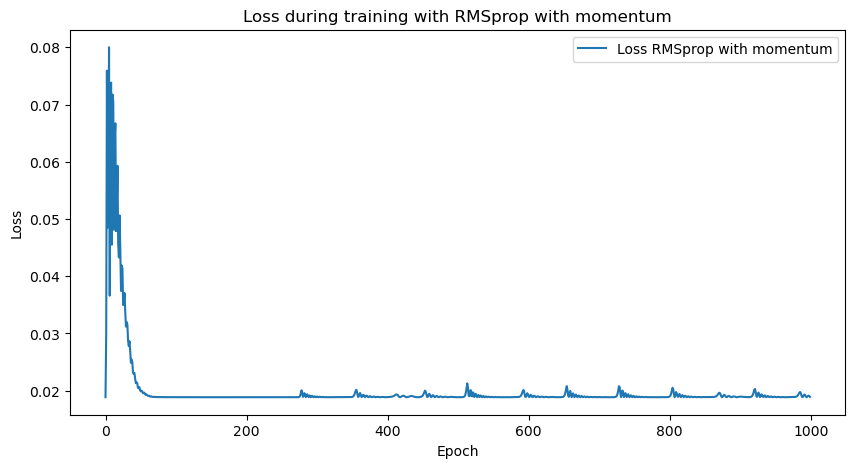

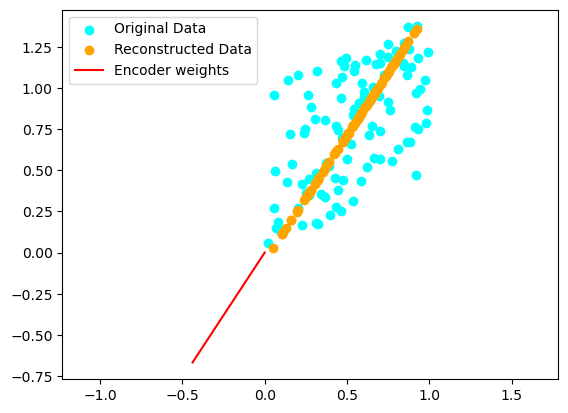

Ratio of encoder weight to decoder weight for dimension 0: 0.6381777891411454
Ratio of encoder weight to decoder weight for dimension 1: 0.6381639056951218


In [1]:
#import libraries
import matplotlib.pyplot as plt
import numpy as np
import torch
import warnings
warnings.filterwarnings('ignore')

#define dimensions
D = 2
x = torch.rand(100, D)
x[:, 1] = 0.5 * x[:, 0] + x[:, 1]  # Correlated synthetic data

#plot
plt.scatter(x[:,0],x[:,1])
plt.axis('equal')

#initialize weights
wEncoder = torch.randn(D, requires_grad=True)
bEncoder = torch.randn(1, requires_grad=True)
wDecoder = torch.randn(D, requires_grad=True)
bDecoder = torch.randn(D, requires_grad=True)

#encoder and decoder functions
def encoder(x):
    z = wEncoder[0] * x[:, 0] + wEncoder[1] * x[:, 1] + bEncoder
    return z

def decoder(z):
    x_recon = torch.empty_like(x)
    x_recon[:, 0] = wDecoder[0] * z + bDecoder[0]
    x_recon[:, 1] = wDecoder[1] * z + bDecoder[1]
    return x_recon

#MSE loss function
def mse_loss(x, x_recon):
    return ((x - x_recon) ** 2).mean()

#training function
def train(optimizer, steps=1000, label="SGD"):
    losses = []
    for step in range(steps):
        z = encoder(x)
        x_recon = decoder(z)
        loss = mse_loss(x, x_recon)
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    #loss plot
    plt.figure(figsize=(10, 5))
    plt.plot(losses, label=f'Loss {label}')
    plt.title(f'Loss during training with {label}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    #weight visualization
    plt.scatter(x[:, 0], x[:, 1], color='cyan', label='Original Data')
    plt.scatter(x_recon.detach()[:, 0], x_recon.detach()[:, 1], color='orange', label='Reconstructed Data')
    plt.plot([0, wEncoder[0].item()], [0, wEncoder[1].item()], 'r-', label='Encoder weights')
    plt.axis('equal')
    plt.legend()
    plt.show()

    #print weight
    print(f"Ratio of encoder weight to decoder weight for dimension 0: {wEncoder[0].item() / wDecoder[0].item()}")
    print(f"Ratio of encoder weight to decoder weight for dimension 1: {wEncoder[1].item() / wDecoder[1].item()}")

#SGD no momentum
sgd_optimizer = torch.optim.SGD([wEncoder, bEncoder, wDecoder, bDecoder], lr=0.01)
train(sgd_optimizer, label="SGD without momentum")

#SGD with momentum
sgd_momentum_optimizer = torch.optim.SGD([wEncoder, bEncoder, wDecoder, bDecoder], lr=0.01, momentum=0.9)
train(sgd_momentum_optimizer, label="SGD with momentum")

#RMSprop with momentum
rmsprop_optimizer = torch.optim.RMSprop([wEncoder, bEncoder, wDecoder, bDecoder], lr=0.01, momentum=0.9)
train(rmsprop_optimizer, label="RMSprop with momentum")


This experiemnt reveaks differences in the model's learning behavior and performace. The visualization of loss over epochs demonstrates distinct patterns of convergence for each optimizer. SGD without momentum shows a gradual and consistne reduction in loss, showing the steady progress typical of this method. Adding momentum to SGD significantly sped up convergence, indicating that momentum aids in overcoming obstacles like local minima or flat gradients by including a velocity component into the parameter. RMSprop with its adaptive learning rates for each parameter shows the fatest and most stable descent, suggesting its efficiency in dealing with varying scale of features.

The scatter plots of original versus construcuted data along with the visual depiction of encoder weight clearly shows the autoencoder's capacity to lean the principal orenation of the data. The encoder weight lines act as visual cues, emphsizing the direction of maximum varieance captured by the model. The proximity of reconstructed points to the original data points confirms the model's effectivness in capturing and reconstructing the essential features. The weight ratios between encoder and decoder furthur validate the symmetry and blance in the model's compresion and reconstruction capabilities.